# 参数驱动的几何体设计与建模

在设计中，参数化建模是一种强大的方法，它允许我们通过调整参数来快速生成和修改几何体。对于结构设计、机械零件和复杂形状的创建尤为重要。但是在空气动力学试验设备的总体气动设计中，我们同样有一种讲究参数化设计的需求，例如调整风洞模型的尺寸以考察不同设计方案。

## CADQuery简介

CADQuery是一个基于Python的开源库，用于创建和操作3D CAD模型。它提供了一种简洁且强大的方式来定义几何体，并支持参数化设计，使得用户可以通过调整参数来生成不同的模型。

### 基本的构造和语法

CADQuery使用链式调用的方式来构建几何体。以下是一些基本的构造方法：

- `Workplane("XY")`：定义一个工作平面，常见的有XY、YZ、XZ等。
- `box(length, width, height)`：创建一个长方体。
- `cylinder(radius, height)`：创建一个圆柱体。
- `sphere(radius)`：创建一个球体。
- `extrude(shape, height)`：沿指定方向拉伸一个2D形状生成3D模型。
- `cut(shape)`：从当前模型中切除另一个形状。
- `union(shape)`：将当前模型与另一个形状合并。
- `translate((x, y, z))`：移动模型到指定位置。
- `rotate((x, y, z), angle)`：绕指定轴旋转模型。

采用Python中的变量和函数，可以轻松实现参数化设计。

### Cadquery示例

下面我们将使用CadQuery库来创建一个简单的参数化长方体模型，并在Jupyter Notebook中展示它。我们将定义长方体的长度、宽度和高度作为参数。

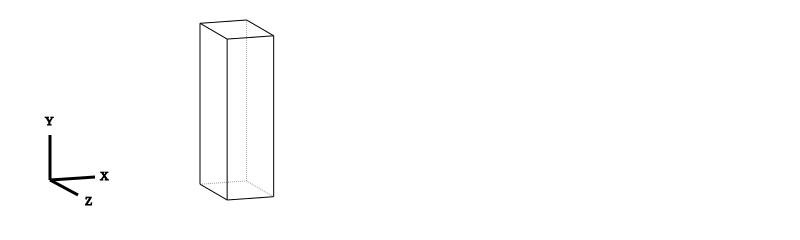

In [ ]:
import cadquery as cq
from IPython.display import SVG

# 参数驱动的几何体设计与建模
length = 100  # 长度参数
width = 50    # 宽度参数
height = 30   # 高度参数

model = cq.Workplane("YZ")

model = (
    model
    .box(length, width, height)
)

# 创建一个参数化的长方体
# box = cq.Workplane("XY").box(length, width, height)
display(SVG(model.toSvg()))  # 显示模型的SVG视图

适当增加一点复杂度，我们可以在长方形中增加一个孔特征。

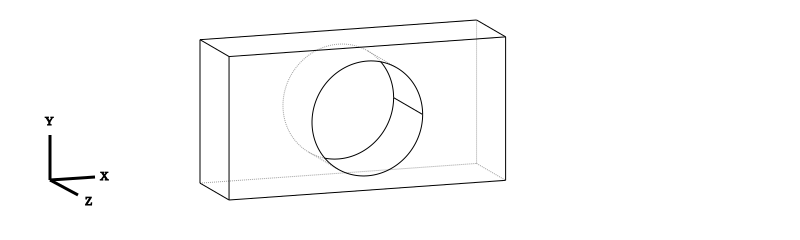

In [27]:
# Define parameters for the model
length = 100
width = 50
height = 30
hole_diameter = 40

model = (
    cq.Workplane("XY")
    .box(length, width, height)
    .faces(">Z").workplane()
    .circle(hole_diameter / 2)
    .cutThruAll()
)

# Display the final model as an SVG.
display(SVG(model.toSvg()))

或者更加复杂，我们增加倒角，增加多个位置的安装孔。这里我们在XY平面上绘制一个正方形，然后在正方形的顶点上开孔，并通过`cutThruAll`函数来切孔。

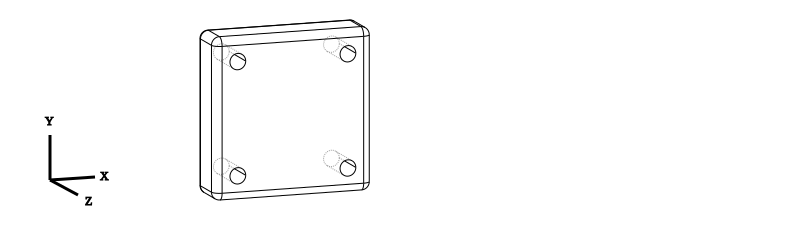

In [23]:
(length, width, height, fillet_radius, hole_diameter, hole_margin) = (
    100, 100, 30, 5, 10, 15
)
model = (
    cq.Workplane("XY")
    .box(length, width, height)
    .edges()
    .fillet(fillet_radius)
    .faces(">Z").workplane()
    .rect(length - 2 * hole_margin, width - 2 * hole_margin, forConstruction=True)
    .vertices()
    .circle(hole_diameter / 2)
    .cutThruAll()
)

display(SVG(model.toSvg()))

## 一个简单的参数化长方体模型示例

我们再次回到前面的长方体，我们可以用三个参数来描述这个最简单的长方体：

- `length`
- `width`
- `height`

分别对应于XYZ三个方向的尺寸。这两个尺寸唯一地定义了长方体。这种定义的唯一性是参数化描述中最重要的特性之一，只有保持了几何定义的唯一性，才能确定明确设计的唯一性，不会引起歧义。

另外一个，就是参数的值域，也就是取值范围。这一方面由参数的内涵——有效性定义，比如，长方体的长度只能是一个一个大于零的实数；另一方面，还会有实际的约束条件，例如我们认为限制三个尺寸都属于区间$[10, 100]$，这个就应该由具体的工程设计问题来确定。

下面给出的代码在Jupyter Notebook/Lab中，可以提供交互的功能，请参考[最佳实践](usage)

In [17]:
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, SVG
import cadquery as cq

# This function is called whenever a slider value changes.
def update_model(length, width, height):
    # 1. Re-create the model with the new dimensions.
    model = cq.Workplane("YZ").box(length, width, height)
    
    # 2. Calculate the volume of the first solid in the model.
    # .val() gets the first solid, .Volume() calculates its volume.
    volume = model.val().Volume()
    
    # 3. Print the calculated volume. The f-string formats it nicely.
    print(f"模型容积 : {volume:,.2f} mm³")
    
    # 4. Return the SVG representation to be displayed in the output.
    display(SVG(model.toSvg()))

# Create interactive sliders that are linked to the 'update_model' function.
interact(
    update_model, 
    length=widgets.IntSlider(min=10, max=200, step=1, value=100, description='长度 mm:'),
    width=widgets.IntSlider(min=10, max=100, step=1, value=50, description='宽度 mm:'),
    height=widgets.IntSlider(min=10, max=100, step=1, value=30, description='高度 mm:')
);

interactive(children=(IntSlider(value=100, description='长度 mm:', max=200, min=10), IntSlider(value=50, descrip…

## 几何访问

前面，我们已经有对几何体的访问示例。

- `model.toSvg()`，将几何体转化为SVG格式的图片
- `model.val().Volume()`，访问几何体的容积参数

当然，CadQuery提供了更多访问几何体属性和数据的方法。这些方法对于验证模型、进行后续分析或与其他系统集成非常有用。

### 访问几何实体

CadQuery模型由不同的几何实体组成，例如顶点（Vertices）、边（Edges）、面（Faces）和实体（Solids）。我们可以通过选择器和函数来访问它们。

- `model.vertices()`: 选择所有顶点。
- `model.edges()`: 选择所有边。
- `model.faces()`: 选择所有面。
- `model.solids()`: 选择所有实体。

我们可以使用选择器来过滤这些实体，例如 `model.faces(">Z")` 选择Z方向上最外侧的面。

### 获取几何属性

一旦选择了实体，就可以获取其属性。

- **包围盒 (Bounding Box)**: `model.val().BoundingBox()` 返回一个描述模型边界的包围盒对象。我们可以从中获取 `xmin`, `xmax`, `ymin`, `ymax`, `zmin`, `zmax` 等属性。
- **质心 (Center of Mass)**: `model.val().Center()` 或 `model.val().CenterOfBoundBox()` 返回模型的质心或包围盒中心。
- **面积 (Area)**: 对于一个面，可以使用 `face.Area()` 获取其面积。

### 导出模型

除了 `toSvg()`，CadQuery还支持将模型导出为多种标准CAD格式，便于在其他软件中使用。

- `cq.exporters.export(model, 'model.step')`: 导出为STEP格式。
- `cq.exporters.export(model, 'model.stl')`: 导出为STL格式。
- `cq.exporters.export(model, 'model.amf')`: 导出为AMF格式。

下面是一个示例，演示如何访问这些几何信息。

模型有个数: 顶点=10, 边=15, 面=7
包围盒 X: (-5.00, 5.00)
包围盒 Y: (-10.00, 10.00)
包围盒 Z: (-15.00, 15.00)
顶面面积: 171.73 mm²
质心: (0.00, 0.00, 0.00)
模型已导出为 STEP 和 STL 文件。


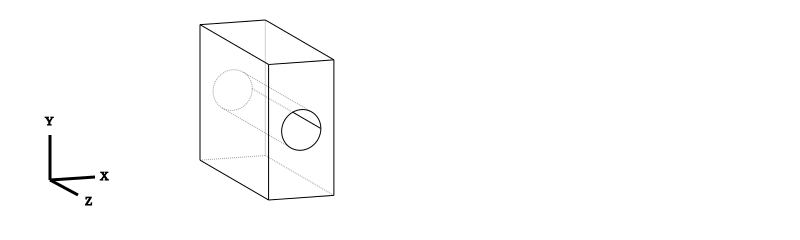

In [29]:
import cadquery as cq
from IPython.display import SVG

# 创建一个简单的模型
model = cq.Workplane("XY").box(10, 20, 30).faces(">Z").circle(3).cutThruAll()

# 1. 访问几何实体数量
num_vertices = len(model.vertices().all())
num_edges = len(model.edges().all())
num_faces = len(model.faces().all())

print(f"模型有个数: 顶点={num_vertices}, 边={num_edges}, 面={num_faces}")

# 2. 获取包围盒信息
bbox = model.val().BoundingBox()
print(f"包围盒 X: ({bbox.xmin:.2f}, {bbox.xmax:.2f})")
print(f"包围盒 Y: ({bbox.ymin:.2f}, {bbox.ymax:.2f})")
print(f"包围盒 Z: ({bbox.zmin:.2f}, {bbox.zmax:.2f})")

# 3. 获取顶层面的面积
top_face = model.faces(">Z").val()
top_face_area = top_face.Area()
print(f"顶面面积: {top_face_area:.2f} mm²")

# 4. 获取质心
center_of_mass = model.val().Center()
print(f"质心: ({center_of_mass.x:.2f}, {center_of_mass.y:.2f}, {center_of_mass.z:.2f})")

# 5. 导出模型 (注意：这将在文件系统中创建文件)
cq.exporters.export(model, 'sample_model.step')
cq.exporters.export(model, 'sample_model.stl')
print("模型已导出为 STEP 和 STL 文件。")

# 显示模型
display(SVG(model.toSvg()))